## Glucose Forecasting with OhioT1DM Data

Prepare `559-ws-training.csv` (5-min CGM + insulin + carbs + steps) for Chronos-2.

### Input format required by `predict_df`
| column | role | notes |
|---|---|---|
| `item_id` | series identifier | one value per participant |
| `timestamp` | datetime | must be regular, gap-free |
| `target` | value to forecast | here: `glucose` |
| other columns | past covariates | basal_amount, dose, total_insulin, carbs, steps |

For a horizon of **X minutes** at 5-min resolution → `prediction_length = X // 5`


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
shared_path = '/content/drive/Shareddrives/Baiying'
os.chdir(shared_path)
print("Working directory:", os.getcwd())

%cd multimodal

Mounted at /content/drive
Working directory: /content/drive/Shareddrives/Baiying
/content/drive/Shareddrives/Baiying/multimodal


In [ ]:
!pwd

/content


In [3]:
%pip install 'chronos-forecasting>=2.2' 'matplotlib'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 135.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.5.0
    Uninstalling huggingface_hub-1.5.0:
      Successfully uninstalled huggingface_hub-1.5.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [4]:
import os

# Use only 1 GPU if available
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline

# Load the Chronos-2 pipeline
# GPU recommended for faster inference, but CPU is also supported using device_map="cpu"
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
from pathlib import Path

# ── Default configuration ──────────────────────────────────────────────────────
FORECAST_HORIZON_MIN = 60    # forecast horizon in minutes
CONTEXT_HOURS        = 12    # rolling context window length in hours
STEP_MIN             = 5     # data resolution in minutes
MAX_GLUCOSE_GAP_MIN  = 30    # glucose gaps > this (min) split into a new sequence
COVARIATE_COLS       = ["basal_amount", "dose", "total_insulin", "carbs", "steps"]
# ───────────────────────────────────────────────────────────────────────────────


def split_at_gaps(grp: pd.DataFrame, expected_delta: pd.Timedelta) -> list[pd.DataFrame]:
    """Split a DataFrame into sub-DataFrames wherever the timestamp gap exceeds expected_delta."""
    grp = grp.reset_index(drop=True)
    diffs = grp["timestamp"].diff()
    gap_positions = grp.index[diffs > expected_delta].tolist()
    if not gap_positions:
        return [grp]
    split_points = [0] + gap_positions + [len(grp)]
    return [grp.iloc[s:e].reset_index(drop=True)
            for s, e in zip(split_points[:-1], split_points[1:])]


def prepare_windows(
    csv_path: str,
    participant_id: str,
    forecast_horizon_min: int = FORECAST_HORIZON_MIN,
    context_hours: int = CONTEXT_HOURS,
    step_min: int = STEP_MIN,
    max_glucose_gap_min: int = MAX_GLUCOSE_GAP_MIN,
    window_step: int | None = None,
    covariate_cols: list[str] | None = None,
    verbose: bool = True,
) -> tuple:
    """
    Load a CGM CSV and build rolling windows for Chronos-2 inference.

    Returns
    -------
    (batch_context_df, batch_future_df, batch_ground_truth_df,
     prediction_length, context_length, covariate_cols)
    All DataFrames are None if no usable windows could be produced.
    """
    if covariate_cols is None:
        covariate_cols = COVARIATE_COLS

    prediction_length = forecast_horizon_min // step_min
    context_length    = (context_hours * 60)  // step_min
    max_gap_steps     = max_glucose_gap_min   // step_min
    window_size       = context_length + prediction_length
    step              = window_step if window_step else prediction_length
    expected_delta    = pd.Timedelta(f"{step_min}min")

    # 1. Load, deduplicate, build complete grid
    raw = pd.read_csv(csv_path)
    raw["timestamp"] = pd.to_datetime(raw["timestamp"])
    raw = raw.sort_values("timestamp").reset_index(drop=True)

    n_before = len(raw)
    raw = raw.drop_duplicates(subset="timestamp", keep="first").reset_index(drop=True)
    n_dupes = n_before - len(raw)
    if n_dupes and verbose:
        print(f"  [{participant_id}] Dropped {n_dupes} duplicate timestamp rows.")

    full_grid = pd.DataFrame({
        "timestamp": pd.date_range(raw["timestamp"].min(), raw["timestamp"].max(),
                                   freq=f"{step_min}min")
    })
    raw = full_grid.merge(raw, on="timestamp", how="left")
    raw[covariate_cols] = raw[covariate_cols].fillna(0)

    # 2. Split on long glucose gaps
    glucose_vals = raw["glucose"].values
    seq_ids = np.zeros(len(raw), dtype=int)
    seq_id, nan_run = 0, 0
    for i, g in enumerate(glucose_vals):
        if np.isnan(g):
            nan_run += 1
        else:
            if nan_run > max_gap_steps:
                seq_id += 1
            nan_run = 0
        seq_ids[i] = seq_id
    raw["seq_id"] = seq_ids

    # 3. Interpolate short gaps, drop remaining NaNs, re-split at residual gaps
    sequences = []
    for sid, grp in raw.groupby("seq_id"):
        grp = grp.copy().reset_index(drop=True)
        grp["glucose"] = grp["glucose"].interpolate(method="linear", limit=max_gap_steps)
        grp = grp.dropna(subset=["glucose"]).reset_index(drop=True)
        grp = grp.drop(columns="seq_id", errors="ignore")
        for sub in split_at_gaps(grp, expected_delta):
            if len(sub) >= window_size:
                sequences.append(sub)

    if verbose:
        print(f"  [{participant_id}] Usable sequences ≥{window_size} steps: {len(sequences)}")

    # 4. Build rolling windows
    all_context, all_future, all_ground_truth = [], [], []
    for seq_idx, seq in enumerate(sequences):
        n = len(seq)
        win_idx = 0
        for start in range(0, n - window_size + 1, step):
            window = seq.iloc[start : start + window_size].copy()
            wid = f"{participant_id}_s{seq_idx}_w{win_idx}"
            window.insert(0, "item_id", wid)
            all_context.append(window.iloc[:context_length].copy())
            all_future.append(
                window.iloc[context_length:][["item_id", "timestamp"] + covariate_cols].copy()
            )
            all_ground_truth.append(
                window.iloc[context_length:][["item_id", "timestamp", "glucose"]].copy()
            )
            win_idx += 1

    if not all_context:
        if verbose:
            print(f"  [{participant_id}] No windows produced — skipping.")
        return None, None, None, prediction_length, context_length, covariate_cols

    batch_context_df      = pd.concat(all_context,      ignore_index=True)
    batch_future_df       = pd.concat(all_future,       ignore_index=True)
    batch_ground_truth_df = pd.concat(all_ground_truth, ignore_index=True)
    n_windows = batch_context_df["item_id"].nunique()

    if verbose:
        print(f"  [{participant_id}] {n_windows} windows  "
              f"| context {batch_context_df.shape}  future {batch_future_df.shape}")

    return (batch_context_df, batch_future_df, batch_ground_truth_df,
            prediction_length, context_length, covariate_cols)


def run_inference(
    pipeline,
    batch_context_df: pd.DataFrame,
    batch_future_df: pd.DataFrame,
    batch_ground_truth_df: pd.DataFrame,
    prediction_length: int,
    save_path: str,
    chunk_size: int = 32,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Run chunked Chronos-2 inference and save results (predictions + ground truth) to save_path.

    Returns
    -------
    results_df : predictions merged with glucose_gt column
    """
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    all_window_ids  = batch_context_df["item_id"].unique().tolist()
    n_windows       = len(all_window_ids)
    all_predictions = []

    for chunk_start in range(0, n_windows, chunk_size):
        chunk_ids  = all_window_ids[chunk_start : chunk_start + chunk_size]
        ctx_chunk  = batch_context_df[batch_context_df["item_id"].isin(chunk_ids)]
        fut_chunk  = batch_future_df[batch_future_df["item_id"].isin(chunk_ids)]

        pred_chunk = pipeline.predict_df(
            ctx_chunk,
            future_df=fut_chunk,
            prediction_length=prediction_length,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="item_id",
            timestamp_column="timestamp",
            target="glucose",
        )
        all_predictions.append(pred_chunk)
        if verbose:
            chunk_end = min(chunk_start + chunk_size, n_windows)
            print(f"    [{chunk_end:4d}/{n_windows}] windows done")

    glucose_pred_df = pd.concat(all_predictions, ignore_index=True)
    results_df = glucose_pred_df.merge(
        batch_ground_truth_df.rename(columns={"glucose": "glucose_gt"}),
        on=["item_id", "timestamp"],
        how="left",
    )
    results_df.to_csv(save_path, index=False)
    if verbose:
        print(f"    Saved → {save_path}")
    return results_df


print("Functions defined: split_at_gaps, prepare_windows, run_inference ✓")


Dropped 584 duplicate timestamp rows.
Gap threshold    : >30 min  (6 steps)
Context length   : 12 h  (144 steps)
Prediction length: 60 min  (12 steps)
Window step      : 12 steps  (non-overlapping)

Usable sequences (≥ 156 steps): 26
  Seq  0:   234 rows  2021-12-07 01:15:00  →  2021-12-07 20:40:00
  Seq  1:   964 rows  2021-12-08 00:05:00  →  2021-12-11 08:20:00
  Seq  2:   641 rows  2021-12-11 09:15:00  →  2021-12-13 14:35:00
  Seq  3:   418 rows  2021-12-14 18:35:00  →  2021-12-16 05:20:00
  Seq  4:   293 rows  2021-12-16 06:15:00  →  2021-12-17 06:35:00
  Seq  5:   352 rows  2021-12-17 20:25:00  →  2021-12-19 01:40:00
  Seq  6:   264 rows  2021-12-19 19:40:00  →  2021-12-20 17:35:00
  Seq  7:   184 rows  2021-12-22 03:05:00  →  2021-12-22 18:20:00
  Seq  8:   571 rows  2021-12-22 18:50:00  →  2021-12-24 18:20:00
  Seq  9:   406 rows  2021-12-24 18:30:00  →  2021-12-26 04:15:00
  Seq 10:   278 rows  2021-12-26 07:15:00  →  2021-12-27 06:20:00
  Seq 11:  1297 rows  2021-12-27 19:10:0

,item_id,timestamp,glucose,basal_amount,dose,total_insulin,carbs,steps
0,559_s0_w0,2021-12-07 01:15:00,101.0,0.054167,0.0,0.054167,0.0,0.0
1,559_s0_w0,2021-12-07 01:20:00,98.0,0.054167,0.0,0.054167,0.0,0.0
2,559_s0_w0,2021-12-07 01:25:00,104.0,0.054167,0.0,0.054167,0.0,0.0


,item_id,timestamp,basal_amount,dose,total_insulin,carbs,steps
0,559_s0_w0,2021-12-07 13:15:00,0.075,0.0,0.075,0.0,1.0
1,559_s0_w0,2021-12-07 13:20:00,0.075,0.0,0.075,0.0,0.0
2,559_s0_w0,2021-12-07 13:25:00,0.075,0.0,0.075,0.0,0.0


,item_id,timestamp,glucose
0,559_s0_w0,2021-12-07 13:15:00,210.0
1,559_s0_w0,2021-12-07 13:20:00,206.0
2,559_s0_w0,2021-12-07 13:25:00,196.0


In [ ]:
# ── Batch inference over all test CSVs ────────────────────────────────────────
TEST_FOLDER  = "/content/drive/Shareddrives/Baiying/multimodal/Ohio/filter_test"
SAVE_FOLDER  = "/content/drive/Shareddrives/Baiying/multimodal/Ohio/predictions/test"
CHUNK_SIZE   = 32    # reduce to 8–16 if GPU OOM

csv_files = sorted(glob.glob(os.path.join(TEST_FOLDER, "*.csv")))
print(f"Found {len(csv_files)} test CSVs\n")

all_results = []

for csv_path in csv_files:
    pid = Path(csv_path).stem.split("-")[0]   # "559" from "559-ws-testing.csv"
    print(f"── {pid} {'─' * 50}")

    ctx_df, fut_df, gt_df, pred_len, ctx_len, cov_cols = prepare_windows(
        csv_path=csv_path,
        participant_id=pid,
    )
    if ctx_df is None:
        print(f"  [{pid}] Skipped — no usable windows.\n")
        continue

    save_path  = os.path.join(SAVE_FOLDER, f"{pid}_glucose_pred.csv")
    results_df = run_inference(
        pipeline=pipeline,
        batch_context_df=ctx_df,
        batch_future_df=fut_df,
        batch_ground_truth_df=gt_df,
        prediction_length=pred_len,
        save_path=save_path,
        chunk_size=CHUNK_SIZE,
    )
    results_df["participant_id"] = pid
    all_results.append(results_df)
    print()

# Save combined results for all participants
combined_df   = pd.concat(all_results, ignore_index=True)
combined_path = os.path.join(SAVE_FOLDER, "all_participants_glucose_pred.csv")
combined_df.to_csv(combined_path, index=False)

print(f"All done!")
print(f"Participants processed : {len(all_results)}")
print(f"Combined shape         : {combined_df.shape}")
print(f"Combined CSV           : {combined_path}")
display(combined_df.head(3))


  [  32/530] windows done
  [  64/530] windows done
  [  96/530] windows done
  [ 128/530] windows done
  [ 160/530] windows done
  [ 192/530] windows done
  [ 224/530] windows done
  [ 256/530] windows done
  [ 288/530] windows done
  [ 320/530] windows done
  [ 352/530] windows done
  [ 384/530] windows done
  [ 416/530] windows done
  [ 448/530] windows done
  [ 480/530] windows done
  [ 512/530] windows done
  [ 530/530] windows done

Predictions shape : (6360, 7)
Results saved to  : /content/drive/Shareddrives/Baiying/multimodal/Ohio/predictions/559_glucose_pred.csv


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,559_s0_w0,2021-12-07 13:15:00,glucose,208.376877,191.931763,208.376877,226.119034
1,559_s0_w0,2021-12-07 13:20:00,glucose,203.750641,174.462860,203.750641,230.061768
2,559_s0_w0,2021-12-07 13:25:00,glucose,199.296906,155.645477,199.296906,234.558365
3,559_s0_w0,2021-12-07 13:30:00,glucose,192.955902,138.269836,192.955902,237.575317
4,559_s0_w0,2021-12-07 13:35:00,glucose,189.104309,125.900665,189.104309,238.956451
5,559_s0_w0,2021-12-07 13:40:00,glucose,182.302338,112.412857,182.302338,243.255737
6,559_s0_w0,2021-12-07 13:45:00,glucose,180.174484,101.848526,180.174484,244.405396
7,559_s0_w0,2021-12-07 13:50:00,glucose,176.293488,91.378441,176.293488,248.578461
8,559_s0_w0,2021-12-07 13:55:00,glucose,172.697388,86.643242,172.697388,246.371521
9,559_s0_w0,2021-12-07 14:00:00,glucose,168.752975,82.364876,168.752975,249.095276


Available windows (530 total):
['559_s0_w0', '559_s0_w1', '559_s0_w2', '559_s0_w3', '559_s0_w4', '559_s0_w5', '559_s0_w6', '559_s1_w0', '559_s1_w1', '559_s1_w2'] ...


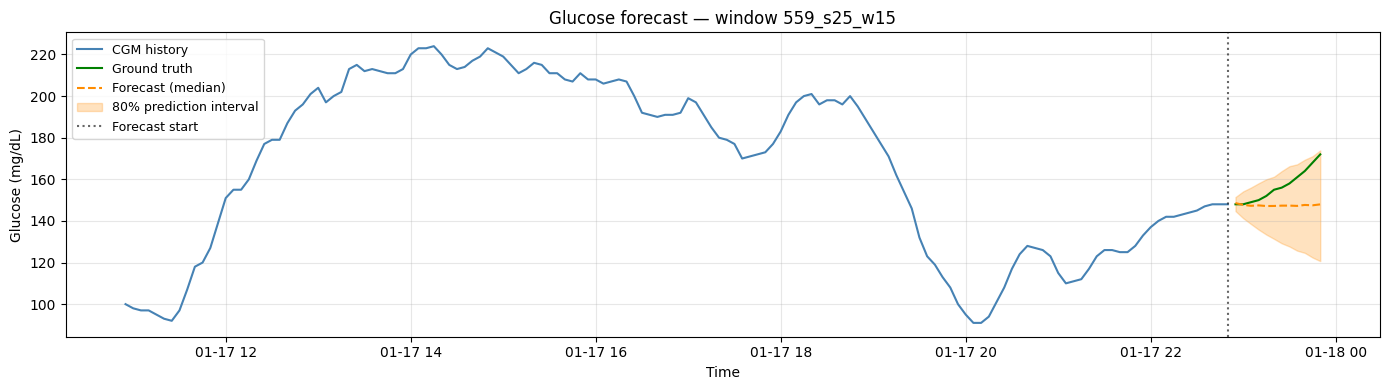

In [20]:
import matplotlib.pyplot as plt

def plot_glucose_forecast(
    context_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    ground_truth_df: pd.DataFrame,
    window_id: str,
    history_steps: int = 144,   # how many context steps to show (default: all 144)
):
    """
    Plot Chronos-2 glucose forecast vs ground truth for one window.

    Parameters
    ----------
    context_df      : batch_context_df  — full context rows for all windows
    pred_df         : glucose_pred_df   — output of pipeline.predict_df()
    ground_truth_df : batch_ground_truth_df — actual glucose for the forecast window
    window_id       : item_id string, e.g. "559_s0_w3"
    history_steps   : number of context steps to display (trim from left if needed)
    """
    # ── Extract this window's data ────────────────────────────────────────────
    ctx = (context_df[context_df["item_id"] == window_id]
           .set_index("timestamp")["glucose"])
    gt  = (ground_truth_df[ground_truth_df["item_id"] == window_id]
           .set_index("timestamp")["glucose"])
    prd = (pred_df[(pred_df["item_id"] == window_id) & (pred_df["target_name"] == "glucose")]
           .set_index("timestamp")[["0.1", "predictions", "0.9"]])

    # Trim context to last `history_steps` for readability
    if len(ctx) > history_steps:
        ctx = ctx.iloc[-history_steps:]

    cutoff = ctx.index[-1]   # last known timestamp

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(ctx.index, ctx.values,
            label="CGM history", color="steelblue", linewidth=1.5)
    ax.plot(gt.index, gt.values,
            label="Ground truth", color="green", linewidth=1.5)
    ax.plot(prd.index, prd["predictions"].values,
            label="Forecast (median)", color="darkorange", linewidth=1.5, linestyle="--")
    ax.fill_between(prd.index, prd["0.1"], prd["0.9"],
                    alpha=0.25, color="darkorange", label="80% prediction interval")
    ax.axvline(x=cutoff, color="black", linestyle=":", alpha=0.6, label="Forecast start")

    ax.set_title(f"Glucose forecast — window {window_id}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Glucose (mg/dL)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── Choose a window to visualise ──────────────────────────────────────────────
all_window_ids = batch_context_df["item_id"].unique().tolist()
print(f"Available windows ({len(all_window_ids)} total):")
print(all_window_ids[:10], "..." if len(all_window_ids) > 10 else "")

# Plot the last window of the first sequence (change index as desired)
PLOT_WINDOW_ID = all_window_ids[-1]
plot_glucose_forecast(batch_context_df, glucose_pred_df, batch_ground_truth_df, PLOT_WINDOW_ID)


In [3]:
"abc".pop()

AttributeError: 'str' object has no attribute 'pop'